# Step 6: Clustering (Unsupervised Core #2)
**INT 396 — Unsupervised Learning | Social Media Topic Discovery for Disaster Response**

12-config matrix: 2 embeddings × 2 reducers × 3 clusterers
- **HDBSCAN** (density-based, handles noise)
- **K-Means** (centroid-based baseline)
- **Agglomerative** (hierarchical, Ward linkage)

Plus optional DBSCAN appendix baseline.

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    pairwise_distances_argmin,
    silhouette_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
import hdbscan

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = str(PROJECT_ROOT)

SEED = 42
np.random.seed(SEED)

In [2]:
# Load all reduced representations
umap_sbert_5d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_sbert_5d.npy", mmap_mode="r")
umap_tfidf_5d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_tfidf_5d.npy", mmap_mode="r")
pca_sbert_50d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_pca_sbert_50d.npy", mmap_mode="r")
svd_tfidf_50d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_svd_tfidf_50d.npy").astype(np.float32, copy=False)

humaid = pd.read_parquet(f"{PROJECT_ROOT}/data/processed/humaid_clean.parquet")
true_labels = humaid["class_label"].values

K_SELECTION_SAMPLE_SIZE = min(12000, len(humaid))
METRIC_SAMPLE_SIZE = min(5000, len(humaid))
AGGLOMERATIVE_SAMPLE_SIZE = min(8000, len(humaid))

def stratified_sample_indices(labels, n_samples, random_state):
    if n_samples >= len(labels):
        return np.arange(len(labels))
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=random_state)
    idx, _ = next(splitter.split(np.zeros(len(labels)), labels))
    return np.sort(idx)

k_selection_idx = stratified_sample_indices(true_labels, K_SELECTION_SAMPLE_SIZE, SEED)
agglo_idx = stratified_sample_indices(true_labels, AGGLOMERATIVE_SAMPLE_SIZE, SEED)

os.makedirs(f"{PROJECT_ROOT}/results", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/figures", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/data/processed", exist_ok=True)

print("Loaded reduced representations:")
print(f"  SBERT + UMAP 5D:          {umap_sbert_5d.shape}")
print(f"  SBERT + PCA 50D:           {pca_sbert_50d.shape}")
print(f"  TF-IDF + UMAP 5D:          {umap_tfidf_5d.shape}")
print(f"  TF-IDF + TruncatedSVD 50D: {svd_tfidf_50d.shape}")
print(f"  K-selection sample:         {len(k_selection_idx):,}")
print(f"  Metric sample size:         {METRIC_SAMPLE_SIZE:,}")
print(f"  Agglomerative sample:       {len(agglo_idx):,}")

# Define the 4 input configurations
inputs = {
    ("SBERT", "UMAP"): umap_sbert_5d,
    ("SBERT", "PCA"): pca_sbert_50d,
    ("TF-IDF", "UMAP"): umap_tfidf_5d,
    ("TF-IDF", "TruncatedSVD"): svd_tfidf_50d,
}

Loaded reduced representations:
  SBERT + UMAP 5D:          (76477, 5)
  SBERT + PCA 50D:           (76477, 50)
  TF-IDF + UMAP 5D:          (76477, 5)
  TF-IDF + TruncatedSVD 50D: (76477, 50)


## 6.1 Determine K for K-Means (Elbow + Silhouette Analysis)

In [3]:
# Find optimal K using a stratified sample to avoid O(n^2) silhouette costs
K_range = range(3, 21)
k_results = {}

elbow_data = {}

for (emb_name, red_name), X in inputs.items():
    X_sample = np.asarray(X[k_selection_idx])
    print(f"\n{emb_name} + {red_name} (sample shape: {X_sample.shape})")
    inertias = []
    sil_scores = []
    
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(X_sample)
        inertias.append(km.inertia_)
        sil = silhouette_score(
            X_sample,
            labels,
            sample_size=min(METRIC_SAMPLE_SIZE, len(X_sample)),
            random_state=SEED,
        )
        sil_scores.append(sil)
        print(f"  K={k:2d}: Silhouette={sil:.4f}", end="  ")
        if k % 6 == 2:
            print()
    
    print()
    best_k = list(K_range)[np.argmax(sil_scores)]
    k_results[(emb_name, red_name)] = best_k
    elbow_data[(emb_name, red_name)] = (inertias, sil_scores)
    print(f"  → Best K = {best_k} (Silhouette = {max(sil_scores):.4f})")

print("\n\nOptimal K per configuration:")
for (emb, red), k in k_results.items():
    print(f"  {emb} + {red}: K={k}")


SBERT + UMAP (shape: (76477, 5))
  K= 3: Silhouette=0.5122    K= 4: Silhouette=0.5841    K= 5: Silhouette=0.6399    K= 6: Silhouette=0.5839    K= 7: Silhouette=0.6084    K= 8: Silhouette=0.5347  
  K= 9: Silhouette=0.5646    K=10: Silhouette=0.5613    K=11: Silhouette=0.5609    K=12: Silhouette=0.5764    K=13: Silhouette=0.5866    K=14: Silhouette=0.5726  
  K=15: Silhouette=0.5824    K=16: Silhouette=0.5579    K=17: Silhouette=0.5611    K=18: Silhouette=0.5575    K=19: Silhouette=0.5548    K=20: Silhouette=0.5753  

  → Best K = 5 (Silhouette = 0.6399)

SBERT + PCA (shape: (76477, 50))
  K= 3: Silhouette=0.0825    K= 4: Silhouette=0.0894    K= 5: Silhouette=0.0901    K= 6: Silhouette=0.0863    K= 7: Silhouette=0.0896    K= 8: Silhouette=0.0947  
  K= 9: Silhouette=0.0973    K=10: Silhouette=0.1020    K=11: Silhouette=0.1062    K=12: Silhouette=0.1068    K=13: Silhouette=0.1057    K=14: Silhouette=0.0973  
  K=15: Silhouette=0.1002    K=16: Silhouette=0.1044    K=17: Silhouette=0.1007

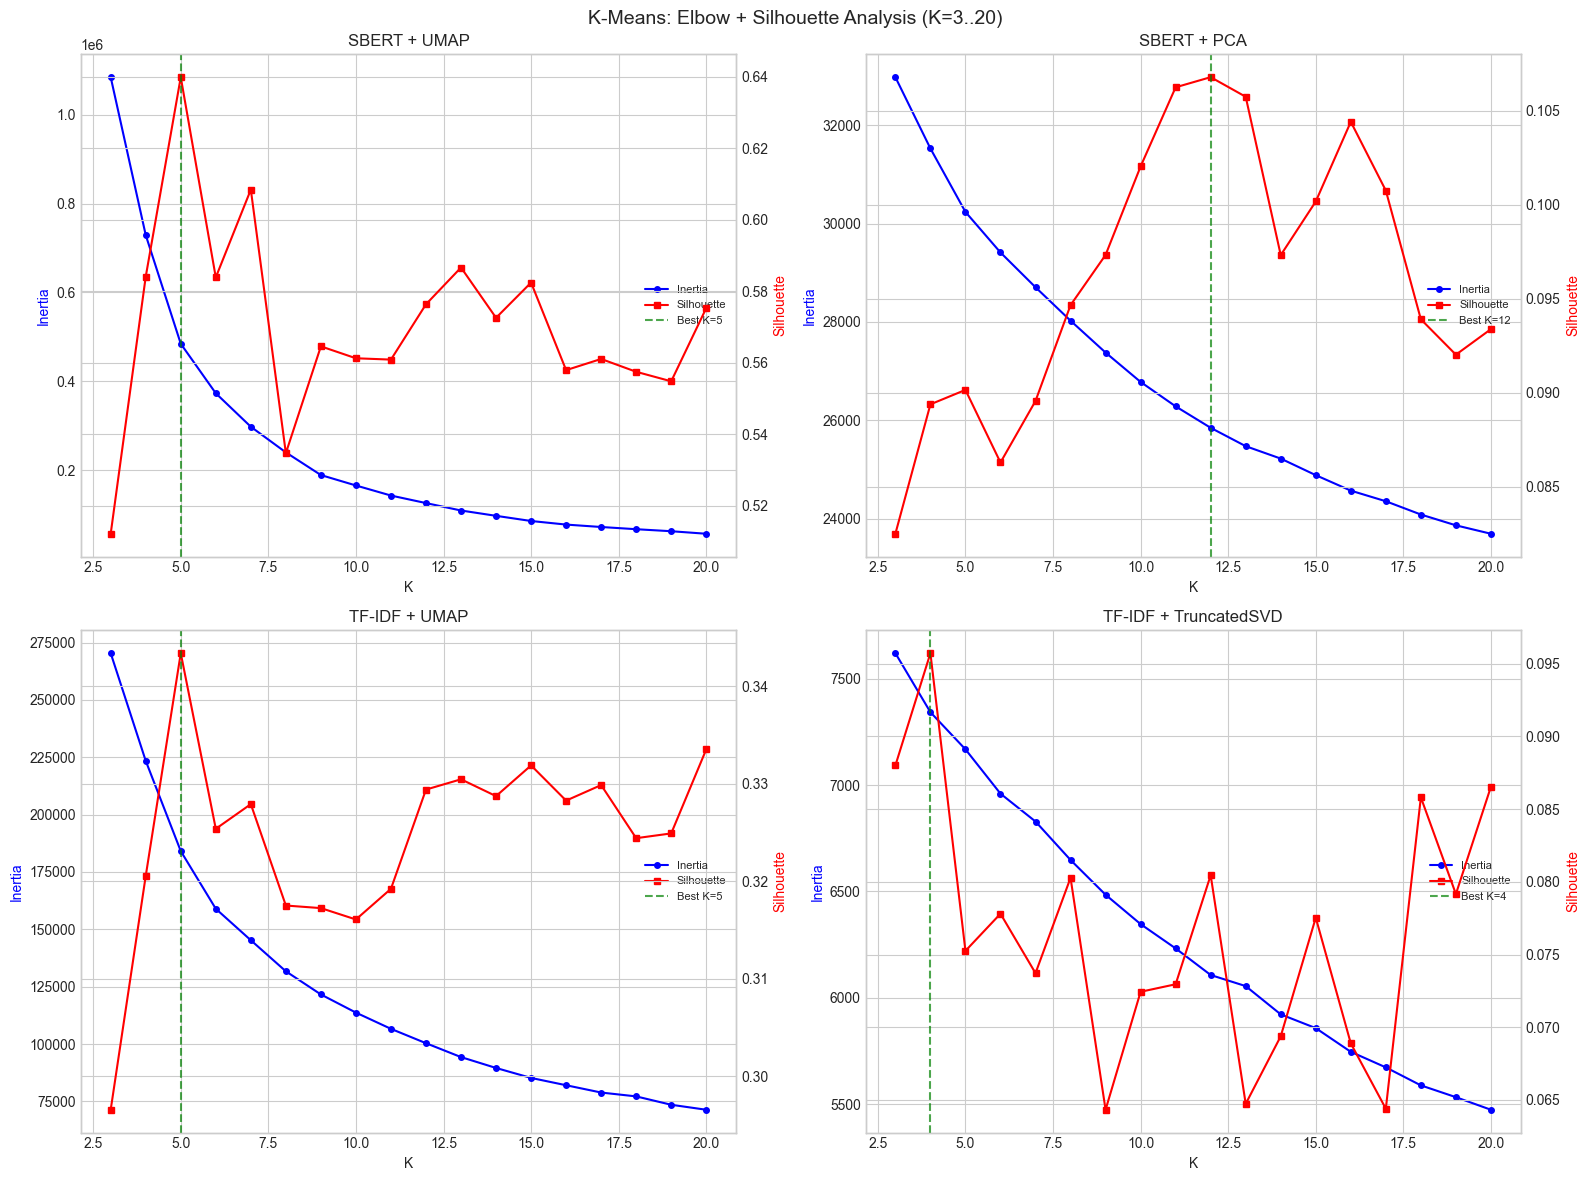

In [4]:
# Plot elbow + silhouette charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for idx, ((emb_name, red_name), (inertias, sil_scores)) in enumerate(elbow_data.items()):
    best_k = k_results[(emb_name, red_name)]
    ax = axes_flat[idx]
    ax2 = ax.twinx()
    ax.plot(list(K_range), inertias, 'b-o', markersize=4, label='Inertia')
    ax2.plot(list(K_range), sil_scores, 'r-s', markersize=4, label='Silhouette')
    ax2.axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
    ax.set_xlabel('K')
    ax.set_ylabel('Inertia', color='b')
    ax2.set_ylabel('Silhouette', color='r')
    ax.set_title(f"{emb_name} + {red_name}")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.suptitle("K-Means: Elbow + Silhouette Analysis (K=3..20)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.2 Run All 12 Configurations

In [ ]:
# Evaluation helper functions
def metric_view(X, labels, sample_size=METRIC_SAMPLE_SIZE, random_state=SEED):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return None, None
    if len(labels) <= sample_size:
        return np.asarray(X), labels
    counts = pd.Series(labels).value_counts()
    valid_labels = counts[counts > 1].index.to_numpy()
    mask = np.isin(labels, valid_labels)
    X_valid = np.asarray(X[mask])
    labels_valid = labels[mask]
    if len(np.unique(labels_valid)) < 2:
        return None, None
    if len(labels_valid) <= sample_size:
        return X_valid, labels_valid
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=random_state)
    idx, _ = next(splitter.split(np.zeros(len(labels_valid)), labels_valid))
    return X_valid[idx], labels_valid[idx]

def safe_silhouette(X, labels, sample_size=METRIC_SAMPLE_SIZE, random_state=SEED):
    X_eval, labels_eval = metric_view(X, labels, sample_size=sample_size, random_state=random_state)
    if X_eval is None:
        return np.nan
    return silhouette_score(X_eval, labels_eval)

def evaluate_convex(X, labels, sample_size=METRIC_SAMPLE_SIZE, random_state=SEED):
    """Compute convex-cluster metrics on a sampled view to keep memory bounded."""
    X_eval, labels_eval = metric_view(X, labels, sample_size=sample_size, random_state=random_state)
    if X_eval is None:
        return {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
    }

def evaluate_density(X, labels, sample_size=METRIC_SAMPLE_SIZE, random_state=SEED):
    """Metrics for HDBSCAN on a sampled non-noise subset."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_mask = labels == -1
    result = {
        "n_clusters": n_clusters,
        "noise_rate": float(noise_mask.sum() / len(labels)),
        "noise_count": int(noise_mask.sum()),
    }
    if n_clusters >= 2 and (~noise_mask).sum() > n_clusters:
        result["silhouette_non_noise"] = safe_silhouette(
            X[~noise_mask],
            labels[~noise_mask],
            sample_size=min(sample_size, (~noise_mask).sum()),
            random_state=random_state,
        )
    else:
        result["silhouette_non_noise"] = np.nan
    return result

def supplementary_agreement(pred_labels, true_labels):
    mask = pred_labels != -1
    if mask.sum() < 10:
        return {"ARI": np.nan, "NMI": np.nan}
    return {
        "ARI": adjusted_rand_score(true_labels[mask], pred_labels[mask]),
        "NMI": normalized_mutual_info_score(true_labels[mask], pred_labels[mask]),
    }

def agglomerative_assign_from_sample(X, n_clusters, sample_idx):
    """Fit ward agglomerative clustering on a stratified sample, then assign all rows by nearest centroid."""
    X_sample = np.asarray(X[sample_idx])
    sample_labels = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward").fit_predict(X_sample)
    centroids = np.vstack([
        X_sample[sample_labels == cluster_id].mean(axis=0)
        for cluster_id in range(n_clusters)
    ])
    full_labels = pairwise_distances_argmin(np.asarray(X), centroids)
    return full_labels

print("Evaluation functions ready. Metrics will use sampled views to avoid kernel crashes.")

In [ ]:
# Run all 12 configurations
all_results = []
all_labels = {}  # Store labels for later analysis

for (emb_name, red_name), X in inputs.items():
    K = k_results[(emb_name, red_name)]
    print(f"\n{'='*60}")
    print(f"{emb_name} + {red_name}")
    print(f"{'='*60}")
    
    # --- HDBSCAN ---
    print(f"  HDBSCAN (tuning min_cluster_size)...")
    best_hdb = None
    best_hdb_score = -np.inf
    for mcs in [50, 100, 200, 500]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=5,
            metric='euclidean',
            gen_min_span_tree=True,
        )
        labels = clusterer.fit_predict(X)
        metrics = evaluate_density(X, labels)
        dbcv = float(getattr(clusterer, 'relative_validity_', np.nan))
        selection_score = dbcv if np.isfinite(dbcv) else metrics['silhouette_non_noise']
        print(
            f"    mcs={mcs}: {metrics['n_clusters']} clusters, "
            f"{metrics['noise_rate']:.1%} noise, DBCV={dbcv:.4f}, "
            f"Sil={metrics['silhouette_non_noise']:.4f}"
        )
        if metrics['n_clusters'] >= 2 and np.isfinite(selection_score) and selection_score > best_hdb_score:
            best_hdb_score = selection_score
            best_hdb = (mcs, labels.copy(), dbcv, metrics)
    
    if best_hdb is not None:
        mcs, hdb_labels, dbcv, metrics = best_hdb
        agreement = supplementary_agreement(hdb_labels, true_labels)
        config_key = f"{emb_name}+{red_name}+HDBSCAN"
        all_labels[config_key] = hdb_labels
        all_results.append({
            "embedding": emb_name, "reducer": red_name, "clusterer": "HDBSCAN",
            "n_clusters": metrics["n_clusters"], "min_cluster_size": mcs,
            "noise_rate": metrics["noise_rate"],
            "DBCV": dbcv,
            "silhouette": metrics["silhouette_non_noise"],
            "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
            "ARI": agreement["ARI"], "NMI": agreement["NMI"],
        })
        print(f"  → Best HDBSCAN: mcs={mcs}, {metrics['n_clusters']} clusters, "
              f"noise={metrics['noise_rate']:.1%}, DBCV={dbcv:.4f}")
    else:
        print(f"  → HDBSCAN failed to find ≥2 clusters")
    
    # --- K-Means ---
    print(f"  K-Means (K={K})...")
    start = time.time()
    km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    km_labels = km.fit_predict(X)
    metrics = evaluate_convex(X, km_labels)
    agreement = supplementary_agreement(km_labels, true_labels)
    config_key = f"{emb_name}+{red_name}+KMeans"
    all_labels[config_key] = km_labels
    all_results.append({
        "embedding": emb_name, "reducer": red_name, "clusterer": "K-Means",
        "n_clusters": K, "min_cluster_size": np.nan,
        "noise_rate": 0.0,
        "DBCV": np.nan,
        "silhouette": metrics["silhouette"],
        "davies_bouldin": metrics["davies_bouldin"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "ARI": agreement["ARI"], "NMI": agreement["NMI"],
    })
    print(f"    Sil={metrics['silhouette']:.4f}, DB={metrics['davies_bouldin']:.4f}, "
          f"CH={metrics['calinski_harabasz']:.0f} ({time.time()-start:.1f}s)")
    
    # --- Agglomerative ---
    print(f"  Agglomerative (sample + centroid assignment, K={K})...")
    start = time.time()
    agg_labels = agglomerative_assign_from_sample(X, K, agglo_idx)
    metrics = evaluate_convex(X, agg_labels)
    agreement = supplementary_agreement(agg_labels, true_labels)
    config_key = f"{emb_name}+{red_name}+Agglomerative"
    all_labels[config_key] = agg_labels
    all_results.append({
        "embedding": emb_name, "reducer": red_name, "clusterer": "Agglomerative",
        "n_clusters": K, "min_cluster_size": np.nan,
        "noise_rate": 0.0,
        "DBCV": np.nan,
        "silhouette": metrics["silhouette"],
        "davies_bouldin": metrics["davies_bouldin"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "ARI": agreement["ARI"], "NMI": agreement["NMI"],
    })
    print(f"    Sil={metrics['silhouette']:.4f}, DB={metrics['davies_bouldin']:.4f}, "
          f"CH={metrics['calinski_harabasz']:.0f} ({time.time()-start:.1f}s)")

print(f"\n{'='*60}")
print(f"All 12 configurations complete!")

## 6.3 Results Comparison Table

In [ ]:
# Build master results DataFrame
results_df = pd.DataFrame(all_results)
results_df["config"] = results_df["embedding"] + " + " + results_df["reducer"] + " + " + results_df["clusterer"]

# Display formatted table
display_cols = ["config", "n_clusters", "noise_rate", "silhouette", "davies_bouldin",
                "calinski_harabasz", "DBCV", "ARI", "NMI"]
print(results_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}" if not np.isnan(x) else "-"))

# Save to CSV
results_df.to_csv(f"{PROJECT_ROOT}/results/clustering_results_12configs.csv", index=False)
print(f"\nSaved: results/clustering_results_12configs.csv")

In [ ]:
# Identify top 3 configurations by silhouette score
top3 = results_df.nlargest(3, "silhouette")
print("Top 3 configurations by Silhouette Score:")
print(top3[["config", "silhouette", "ARI", "NMI"]].to_string(index=False))

# Also show best HDBSCAN by DBCV
hdb_results = results_df[results_df["clusterer"] == "HDBSCAN"].dropna(subset=["DBCV"])
if len(hdb_results) > 0:
    best_hdb = hdb_results.loc[hdb_results["DBCV"].idxmax()]
    print(f"\nBest HDBSCAN by DBCV: {best_hdb['config']} (DBCV={best_hdb['DBCV']:.4f}, "
          f"noise={best_hdb['noise_rate']:.1%})")

## 6.4 Stability Testing (Top 3 Configs × 3 Seeds)

In [ ]:
# Re-run top 3 configs with seeds 42, 123, 456
seeds = [42, 123, 456]
stability_results = []

for _, row in top3.iterrows():
    emb_name = row["embedding"]
    red_name = row["reducer"]
    clust_name = row["clusterer"]
    config = row["config"]
    K = int(row["n_clusters"])
    
    print(f"\nStability test: {config}")
    
    for seed in seeds:
        # Need to re-run UMAP with different seed if UMAP is the reducer
        if red_name == "UMAP":
            import umap as umap_lib
            with open(f"{PROJECT_ROOT}/config/dim_reduction_config.yaml") as f:
                cfg = yaml.safe_load(f)
            key = f"umap_{emb_name.lower()}"
            
            if emb_name == "SBERT":
                raw_emb = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_sbert.npy")
                n_comp = 5
            else:
                import scipy.sparse
                raw_emb = scipy.sparse.load_npz(f"{PROJECT_ROOT}/data/embeddings/humaid_tfidf.npz")
                n_comp = 5
            
            X = umap_lib.UMAP(
                n_components=n_comp,
                n_neighbors=cfg[key]["n_neighbors"],
                min_dist=cfg[key]["min_dist"],
                metric="cosine", random_state=seed
            ).fit_transform(raw_emb)
        else:
            # PCA/SVD are deterministic — same X each time
            X = inputs[(emb_name, red_name)]
        
        if clust_name == "K-Means":
            labels = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(X)
            sil = safe_silhouette(X, labels, random_state=seed)
            ari = adjusted_rand_score(true_labels, labels)
            nmi = normalized_mutual_info_score(true_labels, labels)
        elif clust_name == "Agglomerative":
            labels = agglomerative_assign_from_sample(X, K, agglo_idx)
            sil = safe_silhouette(X, labels, random_state=seed)
            ari = adjusted_rand_score(true_labels, labels)
            nmi = normalized_mutual_info_score(true_labels, labels)
        elif clust_name == "HDBSCAN":
            mcs = int(row["min_cluster_size"]) if not np.isnan(row["min_cluster_size"]) else 100
            labels = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=5, metric='euclidean').fit_predict(X)
            mask = labels != -1
            sil = safe_silhouette(X[mask], labels[mask], random_state=seed) if mask.sum() > 10 else np.nan
            ari = adjusted_rand_score(true_labels[mask], labels[mask]) if mask.sum() > 10 else np.nan
            nmi = normalized_mutual_info_score(true_labels[mask], labels[mask]) if mask.sum() > 10 else np.nan
        
        stability_results.append({
            "config": config, "seed": seed,
            "silhouette": sil, "ARI": ari, "NMI": nmi
        })
        print(f"  seed={seed}: Sil={sil:.4f}, ARI={ari:.4f}, NMI={nmi:.4f}")

stab_df = pd.DataFrame(stability_results)
print("\nStability Summary (mean ± std):")
summary = stab_df.groupby("config").agg(
    sil_mean=("silhouette", "mean"), sil_std=("silhouette", "std"),
    ari_mean=("ARI", "mean"), ari_std=("ARI", "std"),
    nmi_mean=("NMI", "mean"), nmi_std=("NMI", "std"),
)
for config in summary.index:
    r = summary.loc[config]
    print(f"  {config}:")
    print(f"    Silhouette: {r['sil_mean']:.4f} ± {r['sil_std']:.4f}")
    print(f"    ARI:        {r['ari_mean']:.4f} ± {r['ari_std']:.4f}")
    print(f"    NMI:        {r['nmi_mean']:.4f} ± {r['nmi_std']:.4f}")

stab_df.to_csv(f"{PROJECT_ROOT}/results/stability_results.csv", index=False)

## 6.5 Optional: DBSCAN Appendix Baseline

In [ ]:
# DBSCAN on best UMAP representation to demonstrate why HDBSCAN is needed
print("DBSCAN appendix baseline (SBERT + UMAP 5D):")
print("="*60)

dbscan_results = []
for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(umap_sbert_5d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = (labels == -1).sum() / len(labels)
    
    if n_clusters >= 2:
        mask = labels != -1
        sil = safe_silhouette(umap_sbert_5d[mask], labels[mask]) if mask.sum() > 10 else np.nan
    else:
        sil = np.nan
    
    dbscan_results.append({
        "eps": eps, "n_clusters": n_clusters,
        "noise_rate": noise_rate, "silhouette": sil
    })
    print(f"  eps={eps:.1f}: {n_clusters} clusters, {noise_rate:.1%} noise, Sil={sil:.4f}" if not np.isnan(sil) else 
          f"  eps={eps:.1f}: {n_clusters} clusters, {noise_rate:.1%} noise, Sil=N/A")

print("\n→ DBSCAN struggles with variable-density tweet embeddings.")
print("  This demonstrates why HDBSCAN (variable density) is necessary.")

## 6.6 Visualization — Cluster Assignments on 2D Projections

In [ ]:
# Load 2D projections for visualization
umap_sbert_2d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_sbert_2d.npy")
umap_tfidf_2d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_tfidf_2d.npy")
pca_sbert_2d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_pca_sbert_2d.npy")
svd_tfidf_2d = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_svd_tfidf_2d.npy")

viz_map = {
    ("SBERT", "UMAP"): umap_sbert_2d,
    ("SBERT", "PCA"): pca_sbert_2d,
    ("TF-IDF", "UMAP"): umap_tfidf_2d,
    ("TF-IDF", "TruncatedSVD"): svd_tfidf_2d,
}

# Plot the 12 configs in a 4×3 grid
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

row = 0
for (emb_name, red_name), viz_2d in viz_map.items():
    for col, clust_name in enumerate(["HDBSCAN", "K-Means", "Agglomerative"]):
        ax = axes[row, col]
        config_key = f"{emb_name}+{red_name}+{clust_name}"
        
        if config_key in all_labels:
            labels = all_labels[config_key]
            # Color noise points grey for HDBSCAN
            if clust_name == "HDBSCAN":
                noise_mask = labels == -1
                ax.scatter(viz_2d[noise_mask, 0], viz_2d[noise_mask, 1],
                          c='lightgrey', s=0.5, alpha=0.2, rasterized=True)
                ax.scatter(viz_2d[~noise_mask, 0], viz_2d[~noise_mask, 1],
                          c=labels[~noise_mask], cmap='tab20', s=0.5, alpha=0.3, rasterized=True)
            else:
                ax.scatter(viz_2d[:, 0], viz_2d[:, 1],
                          c=labels, cmap='tab20', s=0.5, alpha=0.3, rasterized=True)
        
        ax.set_title(f"{emb_name}+{red_name}+{clust_name}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    row += 1

plt.suptitle("12-Config Clustering Results on 2D Projections", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/clustering_12configs_2d.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.7 Save All Cluster Labels

In [ ]:
# Save cluster labels for each config
labels_df = pd.DataFrame(all_labels)
labels_df.to_parquet(f"{PROJECT_ROOT}/data/processed/cluster_labels_12configs.parquet", index=False)
print(f"Saved cluster labels: {labels_df.shape}")

# Summary
print(f"\n{'='*60}")
print("CLUSTERING SUMMARY")
print(f"{'='*60}")
print(f"Configurations run: {len(results_df)}")
print(f"\nBest by Silhouette:")
best_sil = results_df.loc[results_df['silhouette'].idxmax()]
print(f"  {best_sil['config']}: Sil={best_sil['silhouette']:.4f}")
if len(hdb_results) > 0:
    print(f"\nBest HDBSCAN by DBCV:")
    print(f"  {best_hdb['config']}: DBCV={best_hdb['DBCV']:.4f}")
print(f"\nBest by ARI (supplementary):")
best_ari = results_df.loc[results_df['ARI'].idxmax()]
print(f"  {best_ari['config']}: ARI={best_ari['ARI']:.4f}")
print(f"\nNext step: Run 07_topic_interpretation.ipynb for c-TF-IDF, representative tweets, and cluster labeling.")